Training Samples: (25000, 200)
Testing Samples: (25000, 200)

Model Architecture Summary


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 119ms/step - accuracy: 0.6270 - loss: 0.6428 - val_accuracy: 0.6320 - val_loss: 0.6304
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 95ms/step - accuracy: 0.7193 - loss: 0.5553 - val_accuracy: 0.7004 - val_loss: 0.5651
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 92ms/step - accuracy: 0.8582 - loss: 0.3354 - val_accuracy: 0.7778 - val_loss: 0.5092
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 93ms/step - accuracy: 0.9577 - loss: 0.1301 - val_accuracy: 0.7742 - val_loss: 0.5786
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 99ms/step - accuracy: 0.9926 - loss: 0.0354 - val_accuracy: 0.7698 - val_loss: 0.7003


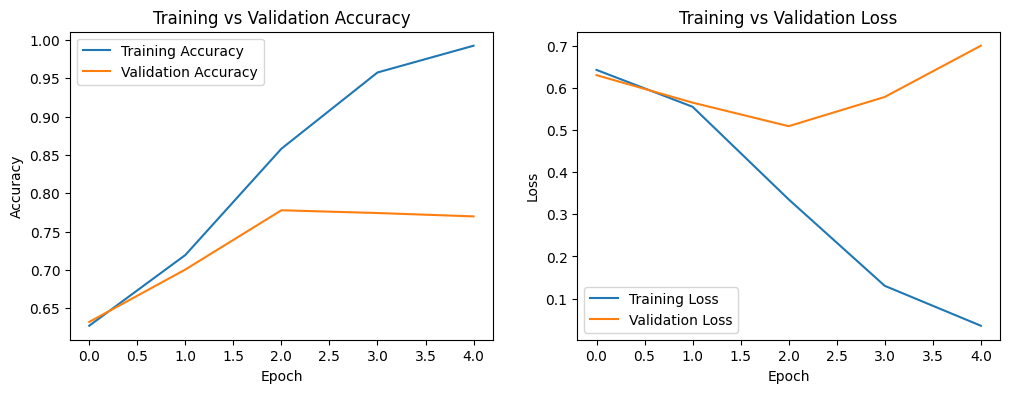

782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.7722 - loss: 0.6996

Model Evaluation
Test Loss: 0.6996115446090698
Test Accuracy: 0.7722399830818176
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step


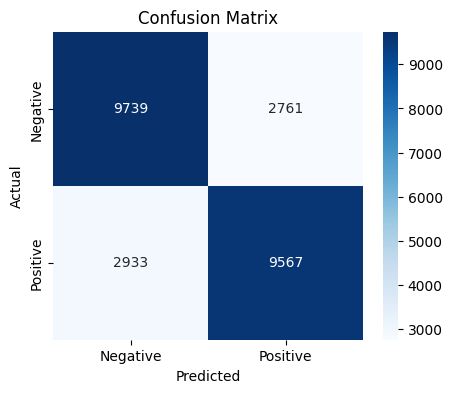


classification Report
              precision    recall  f1-score   support

           0       0.77      0.78      0.77     12500
           1       0.78      0.77      0.77     12500

    accuracy                           0.77     25000
   macro avg       0.77      0.77      0.77     25000
weighted avg       0.77      0.77      0.77     25000


Sample Prediction Interpretation

Review 1
Actual Sentiment : Negative
Predicted Sentiment: Negative
Prediction Confidence: 0.002
----------------------------------------
Review 2
Actual Sentiment : Positive
Predicted Sentiment: Positive
Prediction Confidence: 0.993
----------------------------------------
Review 3
Actual Sentiment : Positive
Predicted Sentiment: Negative
Prediction Confidence: 0.216
----------------------------------------
Review 4
Actual Sentiment : Negative
Predicted Sentiment: Negative
Prediction Confidence: 0.195
----------------------------------------
Review 5
Actual Sentiment : Positive
Predicted Sentiment: Positive


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SimpleRNN # Added SimpleRNN import
from sklearn.metrics import confusion_matrix, classification_report
vocab_size=10000
max_len=200
(x_train,y_train),(x_test,y_test)=imdb.load_data(num_words=vocab_size)
x_train=pad_sequences(x_train,maxlen=max_len)
x_test=pad_sequences(x_test,maxlen=max_len)
print("Training Samples:",x_train.shape)
print("Testing Samples:",x_test.shape)
model= Sequential([Embedding(vocab_size,128,input_length=max_len),SimpleRNN(64),Dense(1,activation='sigmoid')])
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
print("\nModel Architecture Summary")
model.summary()
history = model.fit(x_train,y_train,epochs=5,batch_size=64,validation_split=0.2)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()
test_loss, test_acc = model.evaluate(x_test, y_test)
print("\nModel Evaluation")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)
predictions = model.predict(x_test)
y_pred = (predictions > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
xticklabels=["Negative","Positive"],
yticklabels=["Negative","Positive"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("\nclassification Report")
print(classification_report(y_test,y_pred))
print("\nSample Prediction Interpretation\n")
for i in range(5):
  probability=predictions[i][0]
  predicted_sentiment = "Positive" if probability > 0.5 else "Negative"
  actual_sentiment = "Positive" if y_test[i] == 1 else "Negative"
  print(f"Review {i+1}")
  print("Actual Sentiment :", actual_sentiment)
  print("Predicted Sentiment:", predicted_sentiment)
  print("Prediction Confidence:", round(probability,3))
  print("-"*40)